In [1]:
import sys
import pickle
from pathlib import Path

project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.pairs.data import download_prices
from src.pairs.backtest import backtest_pair

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

In [2]:
prices = download_prices()
with open(project_root / "data" / "processed" / "kalman_results.pkl", "rb") as f:
    kalman_results = pickle.load(f)
print(f"Loaded Kalman results for {len(kalman_results)} pairs")

Loaded Kalman results for 8 pairs


In [3]:
results = {}
summaries = []

for (y, x), kr in kalman_results.items():
    print(f"Backtesting {y}/{x}...", end=" ")
    bt = backtest_pair(
        kalman_result=kr,
        prices=prices,
        entry_sigma=2.0,
        cost_bps_per_leg=10.0,
        burn_in_days=252,
    )
    results[(y, x)] = bt
    s = bt.summary()
    summaries.append(s)
    print(f"n_trades={s['n_trades']}, "
          f"net_pnl={s['total_net_pnl']:.4f}, "
          f"sharpe={s['sharpe_daily']:.2f}")

summary_df = pd.DataFrame(summaries).sort_values("sharpe_daily", ascending=False)
summary_df

Backtesting GS/WFC... n_trades=0, net_pnl=0.0000, sharpe=nan
Backtesting BA/GE... n_trades=0, net_pnl=0.0000, sharpe=nan
Backtesting BA/CAT... n_trades=0, net_pnl=0.0000, sharpe=nan
Backtesting COST/PG... n_trades=0, net_pnl=0.0000, sharpe=nan
Backtesting C/JPM... n_trades=0, net_pnl=0.0000, sharpe=nan
Backtesting AVGO/NVDA... n_trades=1, net_pnl=-0.0890, sharpe=-0.32
Backtesting KO/PG... n_trades=0, net_pnl=0.0000, sharpe=nan
Backtesting CVX/SLB... n_trades=0, net_pnl=0.0000, sharpe=nan


,pair,n_trades,total_net_pnl,win_rate,avg_trade_net,sharpe_daily,max_drawdown,total_gross_pnl,total_costs
5,AVGO/NVDA,1,-0.08902,0.0,-0.08902,-0.316279,-0.121649,-0.08502,0.004
0,GS/WFC,0,0.00000,NaN,NaN,NaN,NaN,NaN,NaN
1,BA/GE,0,0.00000,NaN,NaN,NaN,NaN,NaN,NaN
2,BA/CAT,0,0.00000,NaN,NaN,NaN,NaN,NaN,NaN
3,COST/PG,0,0.00000,NaN,NaN,NaN,NaN,NaN,NaN
4,C/JPM,0,0.00000,NaN,NaN,NaN,NaN,NaN,NaN
6,KO/PG,0,0.00000,NaN,NaN,NaN,NaN,NaN,NaN
7,CVX/SLB,0,0.00000,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
# Daily P&L per pair.
daily_pnls = pd.DataFrame({
    bt.pair: bt.daily_pnl
    for bt in results.values()
    if bt.daily_pnl is not None
})

# Portfolio = equal-weighted average of pair P&Ls.
portfolio_daily = daily_pnls.mean(axis=1)
portfolio_cum = portfolio_daily.cumsum()

# Stats.
n_trading_days = (portfolio_daily != 0).sum()
sharpe = (portfolio_daily.mean() / portfolio_daily.std()) * np.sqrt(252)
total_pnl = portfolio_cum.iloc[-1]

# Max drawdown.
running_max = portfolio_cum.cummax()
drawdown = portfolio_cum - running_max
max_dd = drawdown.min()

print("=== Equal-weighted portfolio (all candidate pairs) ===")
print(f"Annualized Sharpe:    {sharpe:.3f}")
print(f"Total cumulative PnL: {total_pnl:.4f}")
print(f"Max drawdown:         {max_dd:.4f}")
print(f"Win rate (daily):     {(portfolio_daily > 0).mean():.2%}")

=== Equal-weighted portfolio (all candidate pairs) ===
Annualized Sharpe:    -0.316
Total cumulative PnL: -0.0111
Max drawdown:         -0.0152
Win rate (daily):     0.08%


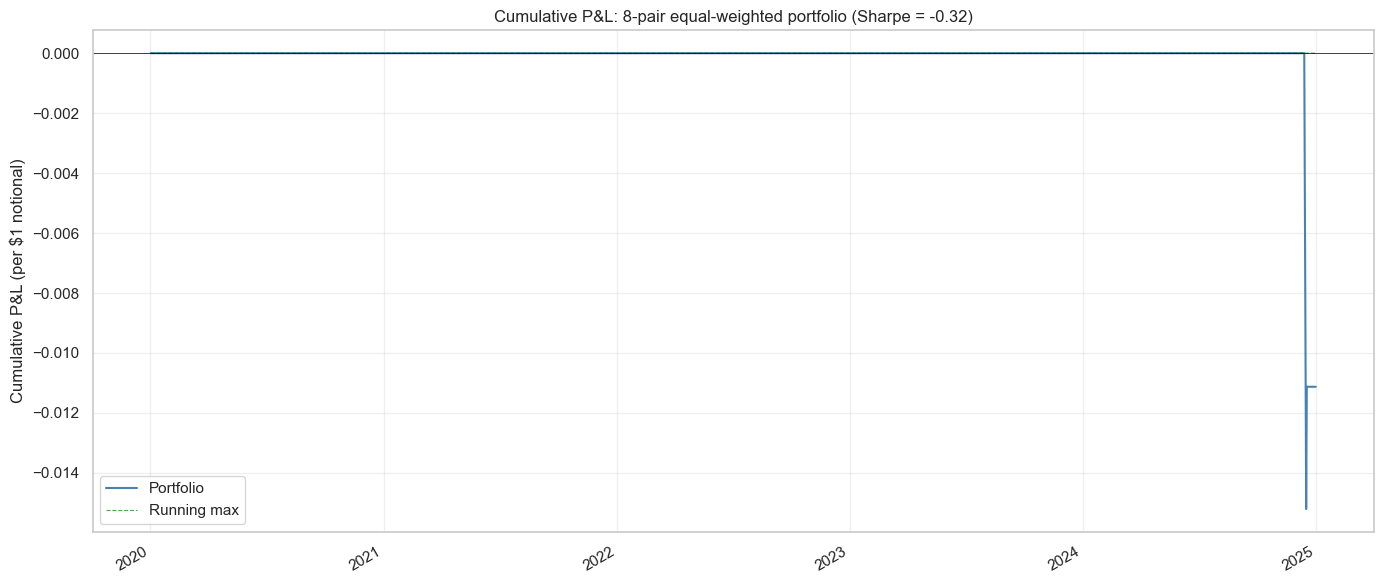

In [5]:
fig, ax = plt.subplots(figsize=(14, 6))
portfolio_cum.plot(ax=ax, color="steelblue", linewidth=1.5, label="Portfolio")
running_max.plot(ax=ax, color="green", linestyle="--", linewidth=0.8, alpha=0.7, label="Running max")
ax.set_title(f"Cumulative P&L: 8-pair equal-weighted portfolio (Sharpe = {sharpe:.2f})")
ax.set_ylabel("Cumulative P&L (per $1 notional)")
ax.axhline(0, color="black", linewidth=0.5)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

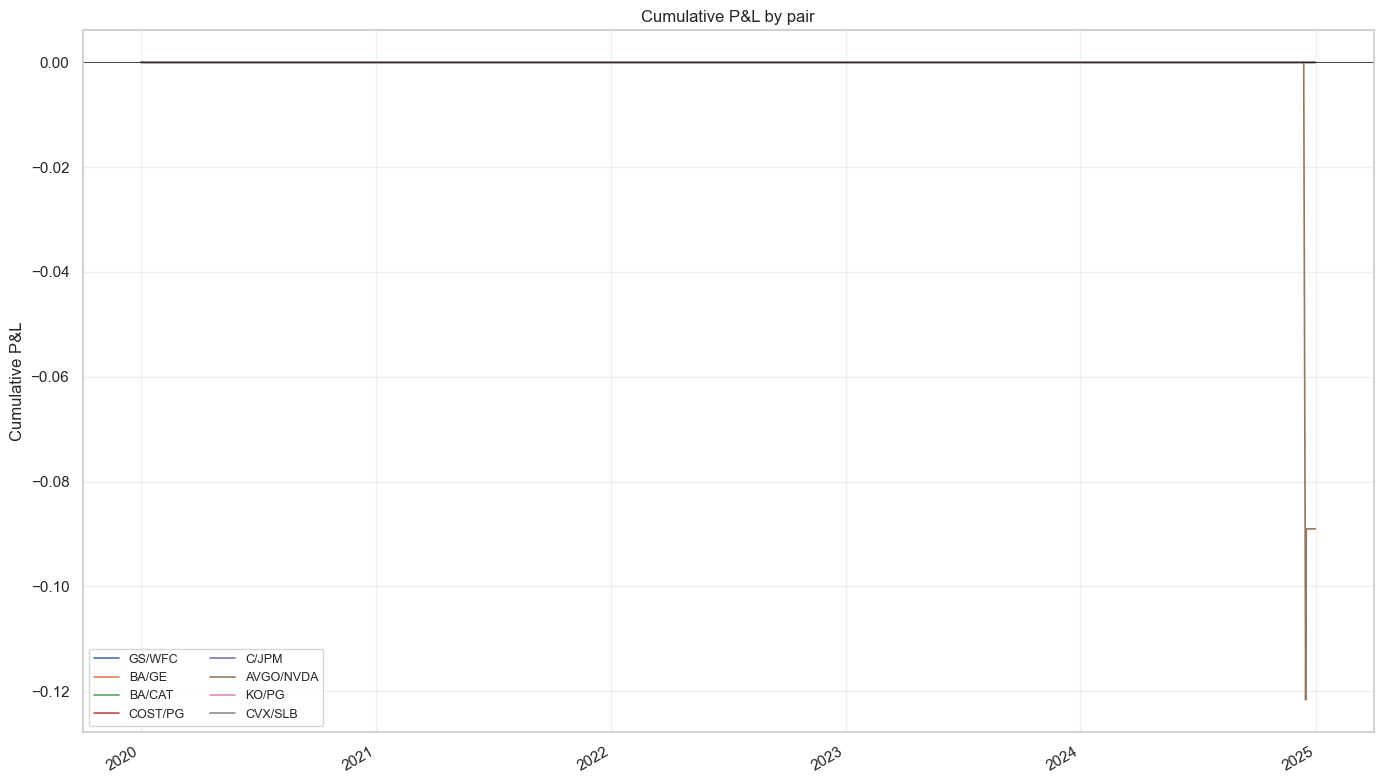

In [6]:
fig, ax = plt.subplots(figsize=(14, 8))
for col in daily_pnls.columns:
    daily_pnls[col].cumsum().plot(ax=ax, label=col, linewidth=1.2)
ax.set_title("Cumulative P&L by pair")
ax.set_ylabel("Cumulative P&L")
ax.axhline(0, color="black", linewidth=0.5)
ax.legend(loc="best", fontsize=9, ncol=2)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [7]:
thresholds = [1.5, 1.75, 2.0, 2.25, 2.5, 3.0]
threshold_results = []

for thr in thresholds:
    daily_per_pair = {}
    for (y, x), kr in kalman_results.items():
        bt = backtest_pair(kr, prices, entry_sigma=thr,
                           cost_bps_per_leg=10.0, burn_in_days=252)
        daily_per_pair[bt.pair] = bt.daily_pnl

    df = pd.DataFrame(daily_per_pair)
    port = df.mean(axis=1)
    sh = (port.mean() / port.std()) * np.sqrt(252) if port.std() > 0 else float("nan")
    n_total_trades = sum(
        backtest_pair(kr, prices, entry_sigma=thr,
                      cost_bps_per_leg=10.0, burn_in_days=252).summary()["n_trades"]
        for (_, _), kr in kalman_results.items()
    )
    threshold_results.append({
        "entry_sigma": thr,
        "n_trades_total": n_total_trades,
        "sharpe": sh,
        "total_pnl": float(port.cumsum().iloc[-1]),
    })

sens_df = pd.DataFrame(threshold_results)
sens_df

,entry_sigma,n_trades_total,sharpe,total_pnl
0,1.50,1,-0.316279,-0.011128
1,1.75,1,-0.316279,-0.011128
2,2.00,1,-0.316279,-0.011128
3,2.25,1,-0.316279,-0.011128
4,2.50,0,NaN,0.000000
5,3.00,0,NaN,0.000000


In [8]:
costs = [0.0, 2.5, 5.0, 10.0, 20.0]
cost_results = []

for c in costs:
    daily_per_pair = {}
    for (y, x), kr in kalman_results.items():
        bt = backtest_pair(kr, prices, entry_sigma=2.0,
                           cost_bps_per_leg=c, burn_in_days=252)
        daily_per_pair[bt.pair] = bt.daily_pnl
    df = pd.DataFrame(daily_per_pair)
    port = df.mean(axis=1)
    sh = (port.mean() / port.std()) * np.sqrt(252) if port.std() > 0 else float("nan")
    cost_results.append({"cost_bps_per_leg": c, "sharpe": sh,
                         "total_pnl": float(port.cumsum().iloc[-1])})

cost_df = pd.DataFrame(cost_results)
cost_df

,cost_bps_per_leg,sharpe,total_pnl
0,0.0,-0.299458,-0.010628
1,2.5,-0.303662,-0.010753
2,5.0,-0.307868,-0.010878
3,10.0,-0.316279,-0.011128
4,20.0,-0.333080,-0.011628


In [9]:
import pickle

with open(project_root / "data" / "processed" / "backtest_results.pkl", "wb") as f:
    pickle.dump(results, f)
summary_df.to_parquet(project_root / "data" / "processed" / "backtest_summary.parquet")
sens_df.to_parquet(project_root / "data" / "processed" / "threshold_sensitivity.parquet")
cost_df.to_parquet(project_root / "data" / "processed" / "cost_sensitivity.parquet")
print("Saved backtest artifacts.")

Saved backtest artifacts.
